<a href="https://colab.research.google.com/github/vinicius-mattoso/industrial-rul-predictive-maintenance/blob/main/notebooks/03_turbine_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wind Turbine Gearbox Fault Detection with 5-Year SCADA Data

This notebook builds a fault/anomaly detection workflow for wind turbine gearbox monitoring using the Kaggle dataset:

`aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada`

The goal is to create an industrial-style workflow for:

- loading SCADA data from Kaggle;
- inspecting labeled gearbox anomaly/fault events;
- building time-aware features;
- training a supervised fault detector when labels are available;
- training an unsupervised anomaly detector as an operational baseline;
- interpreting which signals are driving anomaly/fault risk;
- saving reusable artifacts for an app/backend later.

## 1. Setup

The dataset is downloaded with `kagglehub`. If the package is not installed in the environment, run the install cell below.

In [4]:
# Uncomment if needed.
# !pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn joblib

In [5]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Download Dataset

The expected Kaggle dataset files are:

- `turbine_5yr_complex_data.csv`
- `turbine_5yr_labeled_data.csv`

The workflow below lists whatever is downloaded and automatically prioritizes the labeled file when present.

In [6]:
path = kagglehub.dataset_download(
    "aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada"
)

dataset_path = Path(path)
print("Path to dataset files:", dataset_path)

files = sorted(dataset_path.glob("**/*"))
for file in files:
    if file.is_file():
        print(file.relative_to(dataset_path), f"{file.stat().st_size / 1024**2:.2f} MB")

Using Colab cache for faster access to the 'wind-turbine-gearbox-anomaly-detection-5year-scada' dataset.
Path to dataset files: /kaggle/input/wind-turbine-gearbox-anomaly-detection-5year-scada
turbine_5yr_complex_data.csv 15.46 MB
turbine_5yr_labeled_data.csv 15.99 MB


In [7]:
csv_files = sorted(dataset_path.glob("**/*.csv"))
assert csv_files, "No CSV files found after Kaggle download."

preferred = [file for file in csv_files if "labeled" in file.name.lower()]
data_file = preferred[0] if preferred else csv_files[0]

print("Selected file:", data_file.name)
df = pd.read_csv(data_file)
print(df.shape)
df.head()

Selected file: turbine_5yr_labeled_data.csv
(262800, 9)


,timestamp,gearbox_oil_temp,gearbox_bearing_temp,vibration_x,vibration_y,vibration_z,oil_pressure,particle_count,is_anomaly
0,2025-01-01 00:00:00,60.49,67.06,0.0129,0.0119,0.0149,4.41,120,0
1,2025-01-01 00:10:00,59.88,67.18,0.0125,0.0115,0.0143,4.43,120,0
2,2025-01-01 00:20:00,60.35,66.80,0.0090,0.0083,0.0104,4.31,120,0
3,2025-01-01 00:30:00,60.11,69.30,0.0143,0.0132,0.0165,4.33,120,0
4,2025-01-01 00:40:00,60.77,67.48,0.0167,0.0154,0.0192,4.35,120,0


## 3. Schema Inspection

Before modeling, inspect columns, datatypes, missing values, and possible target/label columns. Kaggle datasets can change over time, so the notebook infers common naming patterns instead of hard-coding one schema.

In [8]:
def normalize_column_name(column: str) -> str:
    return (
        str(column)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

raw_columns = df.columns.tolist()
df = df.rename(columns={column: normalize_column_name(column) for column in df.columns})

schema = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [df[column].dtype for column in df.columns],
        "missing_pct": [df[column].isna().mean() for column in df.columns],
        "nunique": [df[column].nunique(dropna=True) for column in df.columns],
    }
)
schema.sort_values("missing_pct", ascending=False).head(30)

,column,dtype,missing_pct,nunique
0,timestamp,object,0.0,262800
1,gearbox_oil_temp,float64,0.0,3616
2,gearbox_bearing_temp,float64,0.0,3986
3,vibration_x,float64,0.0,598
4,vibration_y,float64,0.0,557
5,vibration_z,float64,0.0,679
6,oil_pressure,float64,0.0,127
7,particle_count,int64,0.0,1589
8,is_anomaly,int64,0.0,2


In [9]:
def infer_datetime_column(data: pd.DataFrame) -> str | None:
    candidates = [
        column for column in data.columns
        if any(token in column for token in ["time", "date", "timestamp", "datetime"])
    ]
    for column in candidates:
        parsed = pd.to_datetime(data[column], errors="coerce")
        if parsed.notna().mean() > 0.8:
            return column
    return None


def infer_target_column(data: pd.DataFrame) -> str | None:
    candidates = [
        column for column in data.columns
        if any(token in column for token in ["label", "target", "fault", "anomaly", "status", "failure"])
    ]
    low_cardinality = [column for column in candidates if data[column].nunique(dropna=True) <= 20]
    return low_cardinality[0] if low_cardinality else (candidates[0] if candidates else None)


datetime_col = infer_datetime_column(df)
target_col = infer_target_column(df)

print("Datetime column:", datetime_col)
print("Target column:", target_col)

if datetime_col:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df = df.sort_values(datetime_col).reset_index(drop=True)

if target_col:
    print(df[target_col].value_counts(dropna=False).head(20))

Datetime column: timestamp
Target column: is_anomaly
is_anomaly
0    257300
1      5500
Name: count, dtype: int64


## 4. Target Engineering

For labeled data, convert the target into a binary problem:

- `0`: normal / healthy
- `1`: anomaly / fault

If the downloaded file does not contain a usable target column, the notebook still runs the unsupervised anomaly detection section.

In [10]:
def build_binary_target(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").fillna(0)
        return (values > 0).astype(int)

    normalized = series.astype(str).str.strip().str.lower()
    normal_tokens = {
        "0", "normal", "healthy", "ok", "good", "false", "no", "none", "no_fault", "not_anomaly"
    }
    return (~normalized.isin(normal_tokens)).astype(int)

if target_col:
    df["is_fault"] = build_binary_target(df[target_col])
    display(df["is_fault"].value_counts(normalize=True).rename("share"))
else:
    df["is_fault"] = np.nan
    print("No target column inferred. Supervised modeling will be skipped.")

,share
is_fault,
0,0.979072
1,0.020928


## 5. SCADA Feature Selection

The model should focus on numeric SCADA signals. We also keep a gearbox-oriented view for interpretation using common component keywords.

In [11]:
identifier_candidates = {target_col, datetime_col, "is_fault"}
identifier_candidates = {column for column in identifier_candidates if column is not None}

numeric_columns = [
    column for column in df.select_dtypes(include=[np.number]).columns
    if column not in identifier_candidates
]

gearbox_keywords = [
    "gear", "gearbox", "bearing", "oil", "temp", "temperature", "vibration", "vib", "speed", "power", "torque", "wind"
]
gearbox_columns = [
    column for column in numeric_columns
    if any(keyword in column for keyword in gearbox_keywords)
]

feature_columns = gearbox_columns if len(gearbox_columns) >= 5 else numeric_columns

print("Numeric columns:", len(numeric_columns))
print("Selected feature columns:", len(feature_columns))
feature_columns[:40]

Numeric columns: 7
Selected feature columns: 6


['gearbox_oil_temp',
 'gearbox_bearing_temp',
 'vibration_x',
 'vibration_y',
 'vibration_z',
 'oil_pressure']

In [12]:
missing_summary = (
    df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .rename("missing_pct")
    .to_frame()
)
missing_summary

,missing_pct
gearbox_oil_temp,0.0
gearbox_bearing_temp,0.0
vibration_x,0.0
vibration_y,0.0
vibration_z,0.0
oil_pressure,0.0


## 6. Exploratory Analysis

Inspect target imbalance and major SCADA signal behavior. Fault detection data is usually imbalanced, so PR-AUC and recall are more useful than accuracy alone.

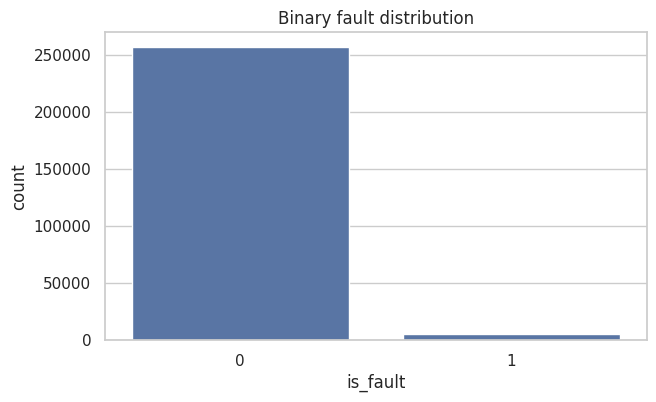

In [13]:
if target_col:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.countplot(data=df, x="is_fault", ax=ax)
    ax.set_title("Binary fault distribution")
    ax.set_xlabel("is_fault")
    ax.set_ylabel("count")
    plt.show()

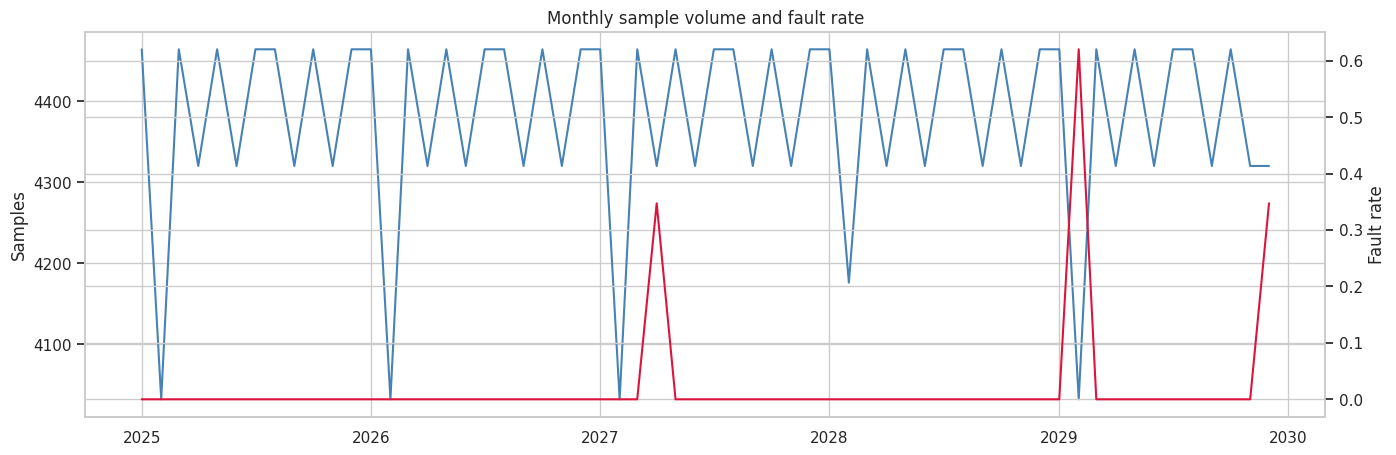

In [14]:
if datetime_col:
    plot_df = df[[datetime_col, "is_fault"]].copy()
    plot_df["period"] = plot_df[datetime_col].dt.to_period("M").dt.to_timestamp()
    monthly = plot_df.groupby("period")["is_fault"].agg(["count", "sum", "mean"]).reset_index()

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax1.plot(monthly["period"], monthly["count"], label="Samples", color="steelblue")
    ax1.set_ylabel("Samples")
    ax2 = ax1.twinx()
    ax2.plot(monthly["period"], monthly["mean"], label="Fault rate", color="crimson")
    ax2.set_ylabel("Fault rate")
    ax1.set_title("Monthly sample volume and fault rate")
    plt.show()

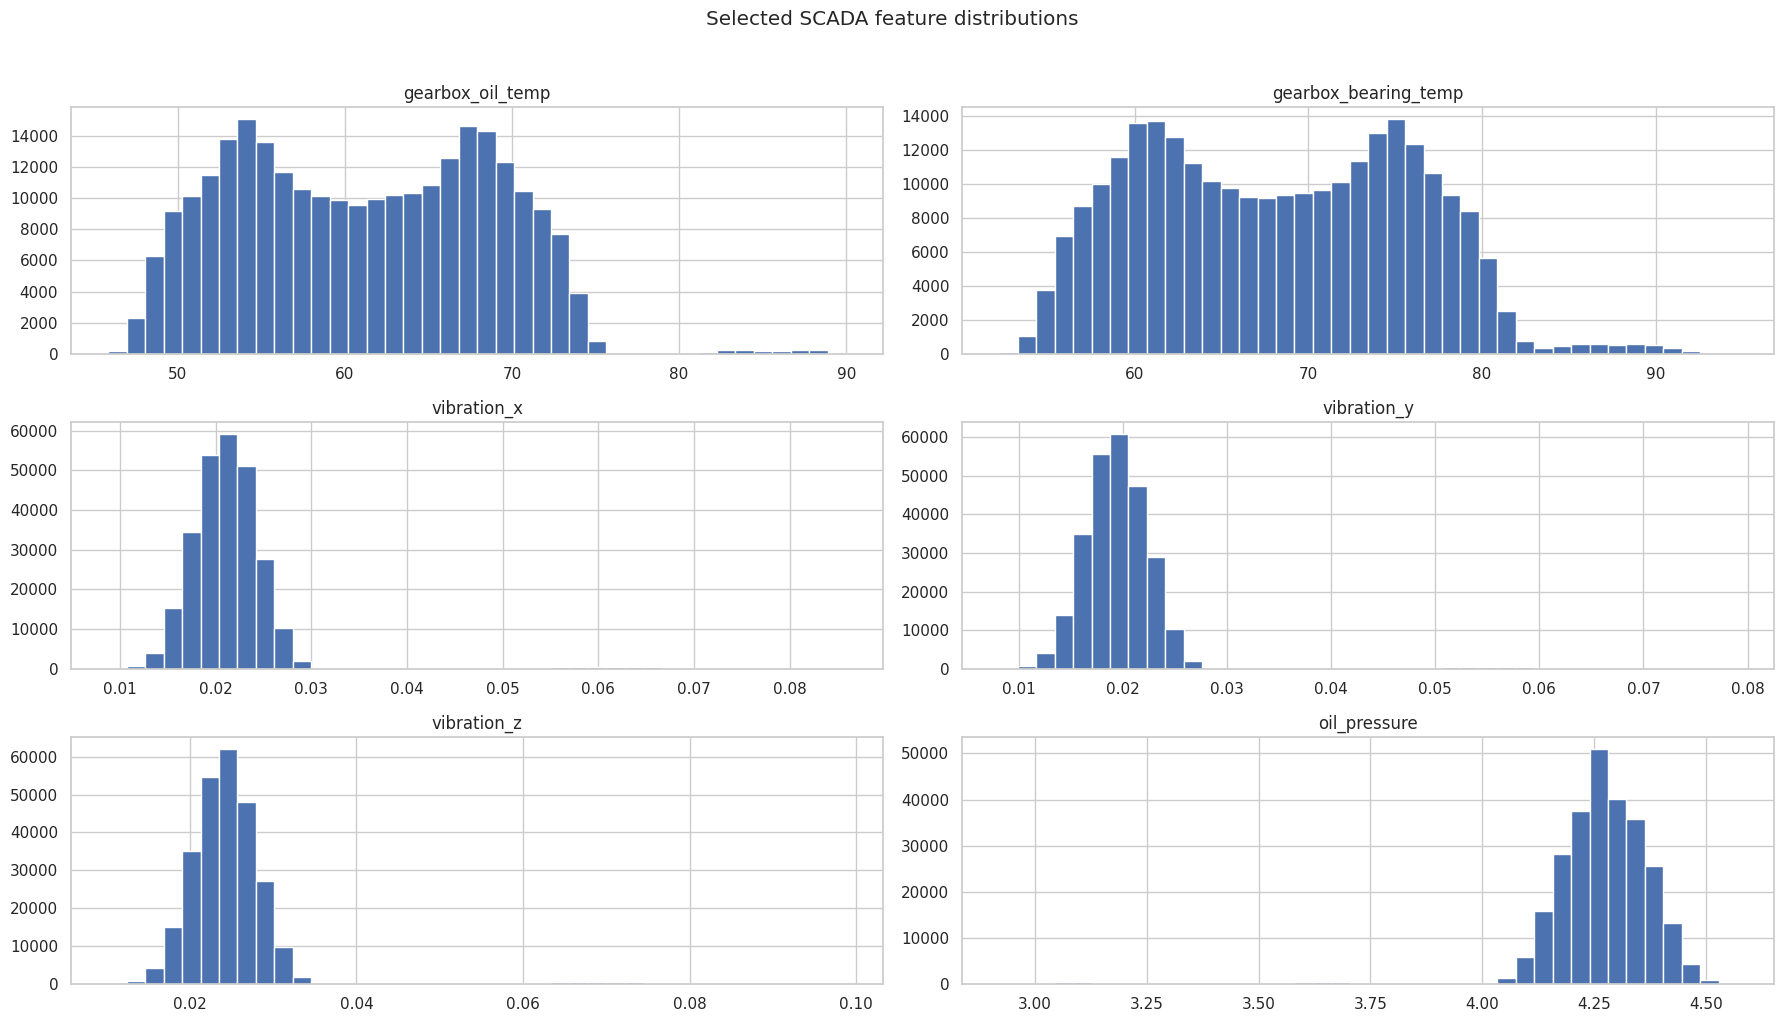

In [15]:
# Quick distribution view for the first selected signals.
preview_features = feature_columns[:12]
if preview_features:
    df[preview_features].hist(figsize=(18, 10), bins=40)
    plt.suptitle("Selected SCADA feature distributions", y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Time-Aware Feature Engineering

SCADA fault behavior is temporal. Create rolling and delta features for the selected signals.

For a first notebook, use global rolling windows. If the dataset has multiple turbine IDs, this can be extended to group by turbine before rolling.

In [16]:
model_df = df.copy()

ROLLING_WINDOWS = [6, 24]
base_features = feature_columns.copy()

for column in base_features:
    for window in ROLLING_WINDOWS:
        model_df[f"{column}_rolling_mean_{window}"] = model_df[column].rolling(window=window, min_periods=1).mean()
        model_df[f"{column}_rolling_std_{window}"] = model_df[column].rolling(window=window, min_periods=2).std()
    model_df[f"{column}_delta_1"] = model_df[column].diff(1)
    model_df[f"{column}_delta_6"] = model_df[column].diff(6)

engineered_features = [
    column for column in model_df.columns
    if column in base_features or "rolling_" in column or "_delta_" in column
]

model_df[engineered_features] = model_df[engineered_features].replace([np.inf, -np.inf], np.nan)
print("Total engineered features:", len(engineered_features))

Total engineered features: 42


## 8. Temporal Train/Test Split

Use a chronological split to avoid leakage. Fault detection should be evaluated on future periods relative to training.

In [17]:
valid_rows = model_df[engineered_features].notna().sum(axis=1) > 0
if target_col:
    valid_rows = valid_rows & model_df["is_fault"].notna()

model_df = model_df.loc[valid_rows].reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[engineered_features]
X_test = test_df[engineered_features]

y_train = train_df["is_fault"].astype(int) if target_col else None
y_test = test_df["is_fault"].astype(int) if target_col else None

print("Train:", X_train.shape)
print("Test:", X_test.shape)
if target_col:
    print("Train fault rate:", y_train.mean())
    print("Test fault rate:", y_test.mean())

Train: (210240, 42)
Test: (52560, 42)
Train fault rate: 0.007134703196347032
Test fault rate: 0.076103500761035


## 9. Supervised Fault Detection Baseline

Train a Random Forest classifier with class balancing. This gives a first supervised benchmark and feature importance.

In [18]:
supervised_model = None
supervised_metrics = {}

if target_col and y_train.nunique() > 1:
    supervised_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=5,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    supervised_model.fit(X_train, y_train)

    y_pred = supervised_model.predict(X_test)
    y_score = supervised_model.predict_proba(X_test)[:, 1]

    supervised_metrics = {
        "roc_auc": roc_auc_score(y_test, y_score) if y_test.nunique() > 1 else np.nan,
        "average_precision": average_precision_score(y_test, y_score),
    }

    print(json.dumps(supervised_metrics, indent=2))
    print(classification_report(y_test, y_pred, digits=4))
else:
    print("Supervised model skipped: no usable labeled target or only one class in train.")

{
  "roc_auc": 0.7334449135090609,
  "average_precision": 0.4719843563176168
}
              precision    recall  f1-score   support

           0     0.9239    1.0000    0.9604     48560
           1     0.0000    0.0000    0.0000      4000

    accuracy                         0.9239     52560
   macro avg     0.4619    0.5000    0.4802     52560
weighted avg     0.8536    0.9239    0.8873     52560



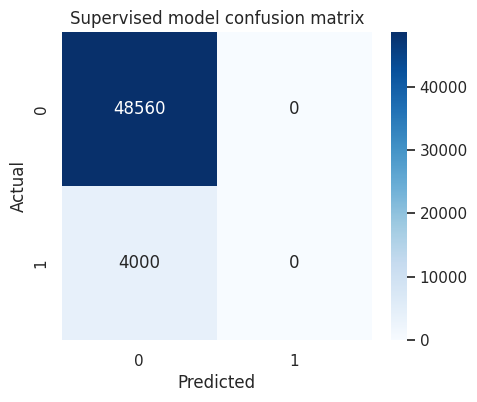

In [19]:
if supervised_model is not None:
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("Supervised model confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.show()

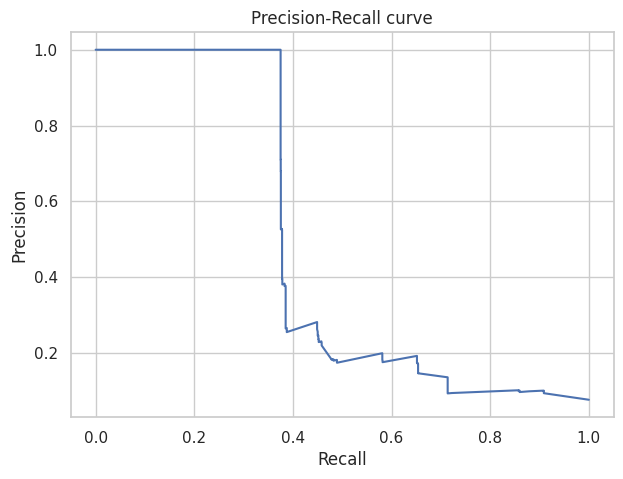

In [20]:
if supervised_model is not None:
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall, precision)
    ax.set_title("Precision-Recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    plt.show()

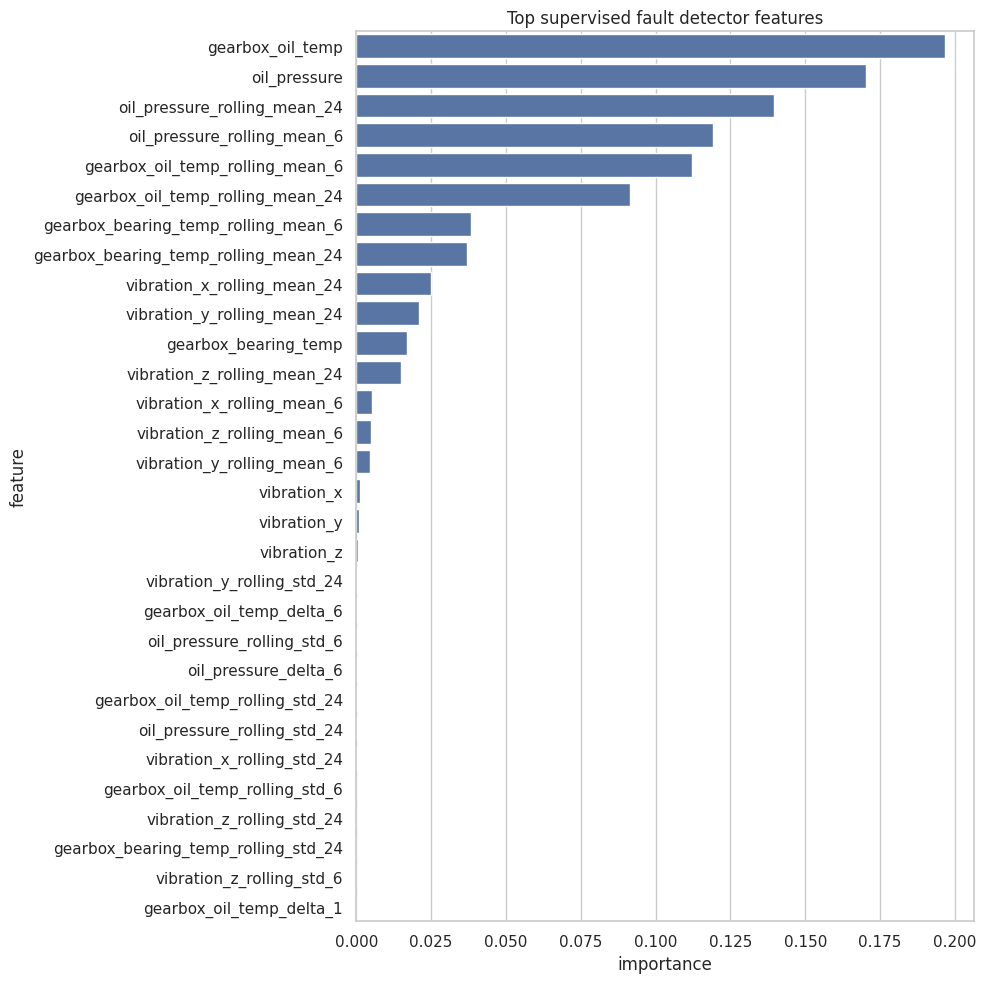

In [21]:
if supervised_model is not None:
    rf = supervised_model.named_steps["model"]
    importance_df = (
        pd.DataFrame({"feature": engineered_features, "importance": rf.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(30)
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    sns.barplot(data=importance_df, x="importance", y="feature", ax=ax)
    ax.set_title("Top supervised fault detector features")
    plt.tight_layout()
    plt.show()

    importance_df

## 10. Unsupervised Anomaly Detection Baseline

Train an Isolation Forest. When labels are available, train on normal observations only to approximate a normal behavior model.

In [22]:
if target_col:
    normal_train_mask = y_train == 0
    anomaly_train_data = X_train.loc[normal_train_mask]
else:
    anomaly_train_data = X_train

anomaly_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=300,
                contamination="auto",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

anomaly_model.fit(anomaly_train_data)

# Larger score means more anomalous.
train_anomaly_score = -anomaly_model.decision_function(X_train)
test_anomaly_score = -anomaly_model.decision_function(X_test)

threshold = np.quantile(train_anomaly_score, 0.995)
test_anomaly_pred = (test_anomaly_score >= threshold).astype(int)

print("Anomaly score threshold:", threshold)
if target_col:
    print(classification_report(y_test, test_anomaly_pred, digits=4))
    print("Average precision:", average_precision_score(y_test, test_anomaly_score))

Anomaly score threshold: 0.05286003478814468
              precision    recall  f1-score   support

           0     1.0000    0.9498    0.9742     48560
           1     0.6212    0.9998    0.7662      4000

    accuracy                         0.9536     52560
   macro avg     0.8106    0.9748    0.8702     52560
weighted avg     0.9711    0.9536    0.9584     52560

Average precision: 0.9885137275671336


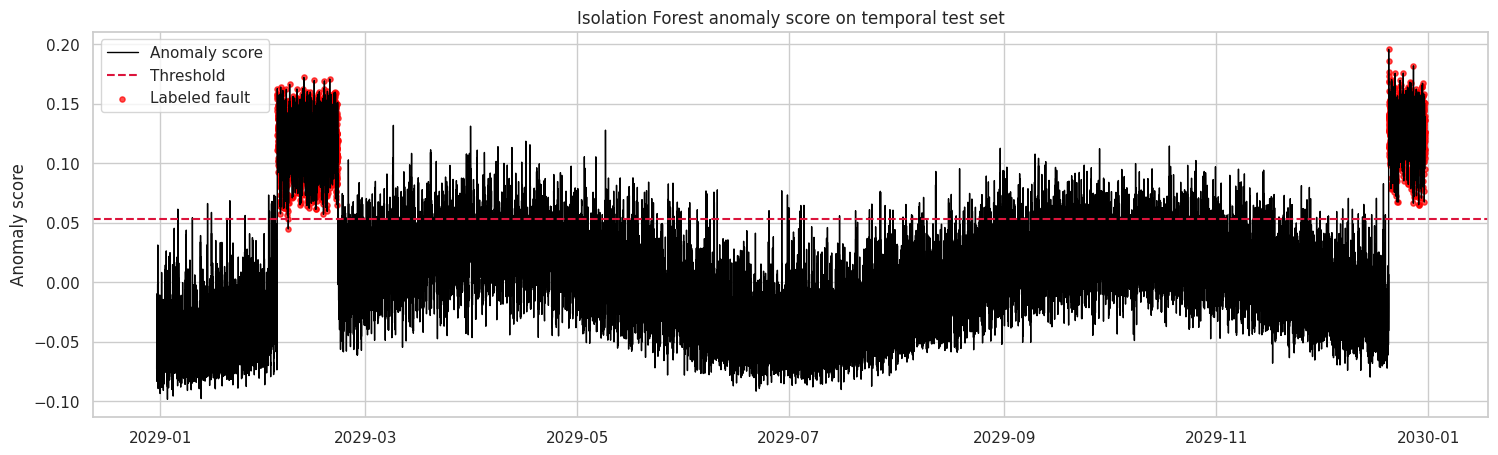

In [23]:
score_plot = test_df[[datetime_col]].copy() if datetime_col else pd.DataFrame(index=test_df.index)
score_plot["anomaly_score"] = test_anomaly_score
score_plot["predicted_anomaly"] = test_anomaly_pred
if target_col:
    score_plot["is_fault"] = y_test.values

fig, ax = plt.subplots(figsize=(18, 5))
x_axis = score_plot[datetime_col] if datetime_col else np.arange(len(score_plot))
ax.plot(x_axis, score_plot["anomaly_score"], label="Anomaly score", color="black", linewidth=1)
ax.axhline(threshold, color="crimson", linestyle="--", label="Threshold")
if target_col:
    fault_points = score_plot[score_plot["is_fault"] == 1]
    ax.scatter(
        fault_points[datetime_col] if datetime_col else fault_points.index,
        fault_points["anomaly_score"],
        color="red",
        s=14,
        label="Labeled fault",
        alpha=0.7,
    )
ax.set_title("Isolation Forest anomaly score on temporal test set")
ax.set_ylabel("Anomaly score")
ax.legend()
plt.show()

## 11. Fault/Anomaly Case Investigation

Inspect the highest-risk timestamps and compare important SCADA signals around those periods.

In [24]:
case_df = test_df.copy()
case_df["anomaly_score"] = test_anomaly_score
if supervised_model is not None:
    case_df["supervised_fault_probability"] = y_score

case_columns = [column for column in [datetime_col, target_col, "is_fault", "anomaly_score", "supervised_fault_probability"] if column in case_df.columns]
case_df[case_columns].sort_values("anomaly_score", ascending=False).head(20)

,timestamp,is_anomaly,is_fault,anomaly_score,supervised_fault_probability
261300,2029-12-20 14:00:00,1,1,0.195798,0.158275
261302,2029-12-20 14:20:00,1,1,0.186112,0.214866
262328,2029-12-27 17:20:00,1,1,0.181871,0.451618
261301,2029-12-20 14:10:00,1,1,0.176392,0.312019
261905,2029-12-24 18:50:00,1,1,0.175751,0.451611
261569,2029-12-22 10:50:00,1,1,0.175656,0.404960
261303,2029-12-20 14:30:00,1,1,0.173719,0.251533
216340,2029-02-11 08:40:00,1,1,0.172192,0.006643
217413,2029-02-18 19:30:00,1,1,0.170833,0.009967
261423,2029-12-21 10:30:00,1,1,0.170368,0.268211


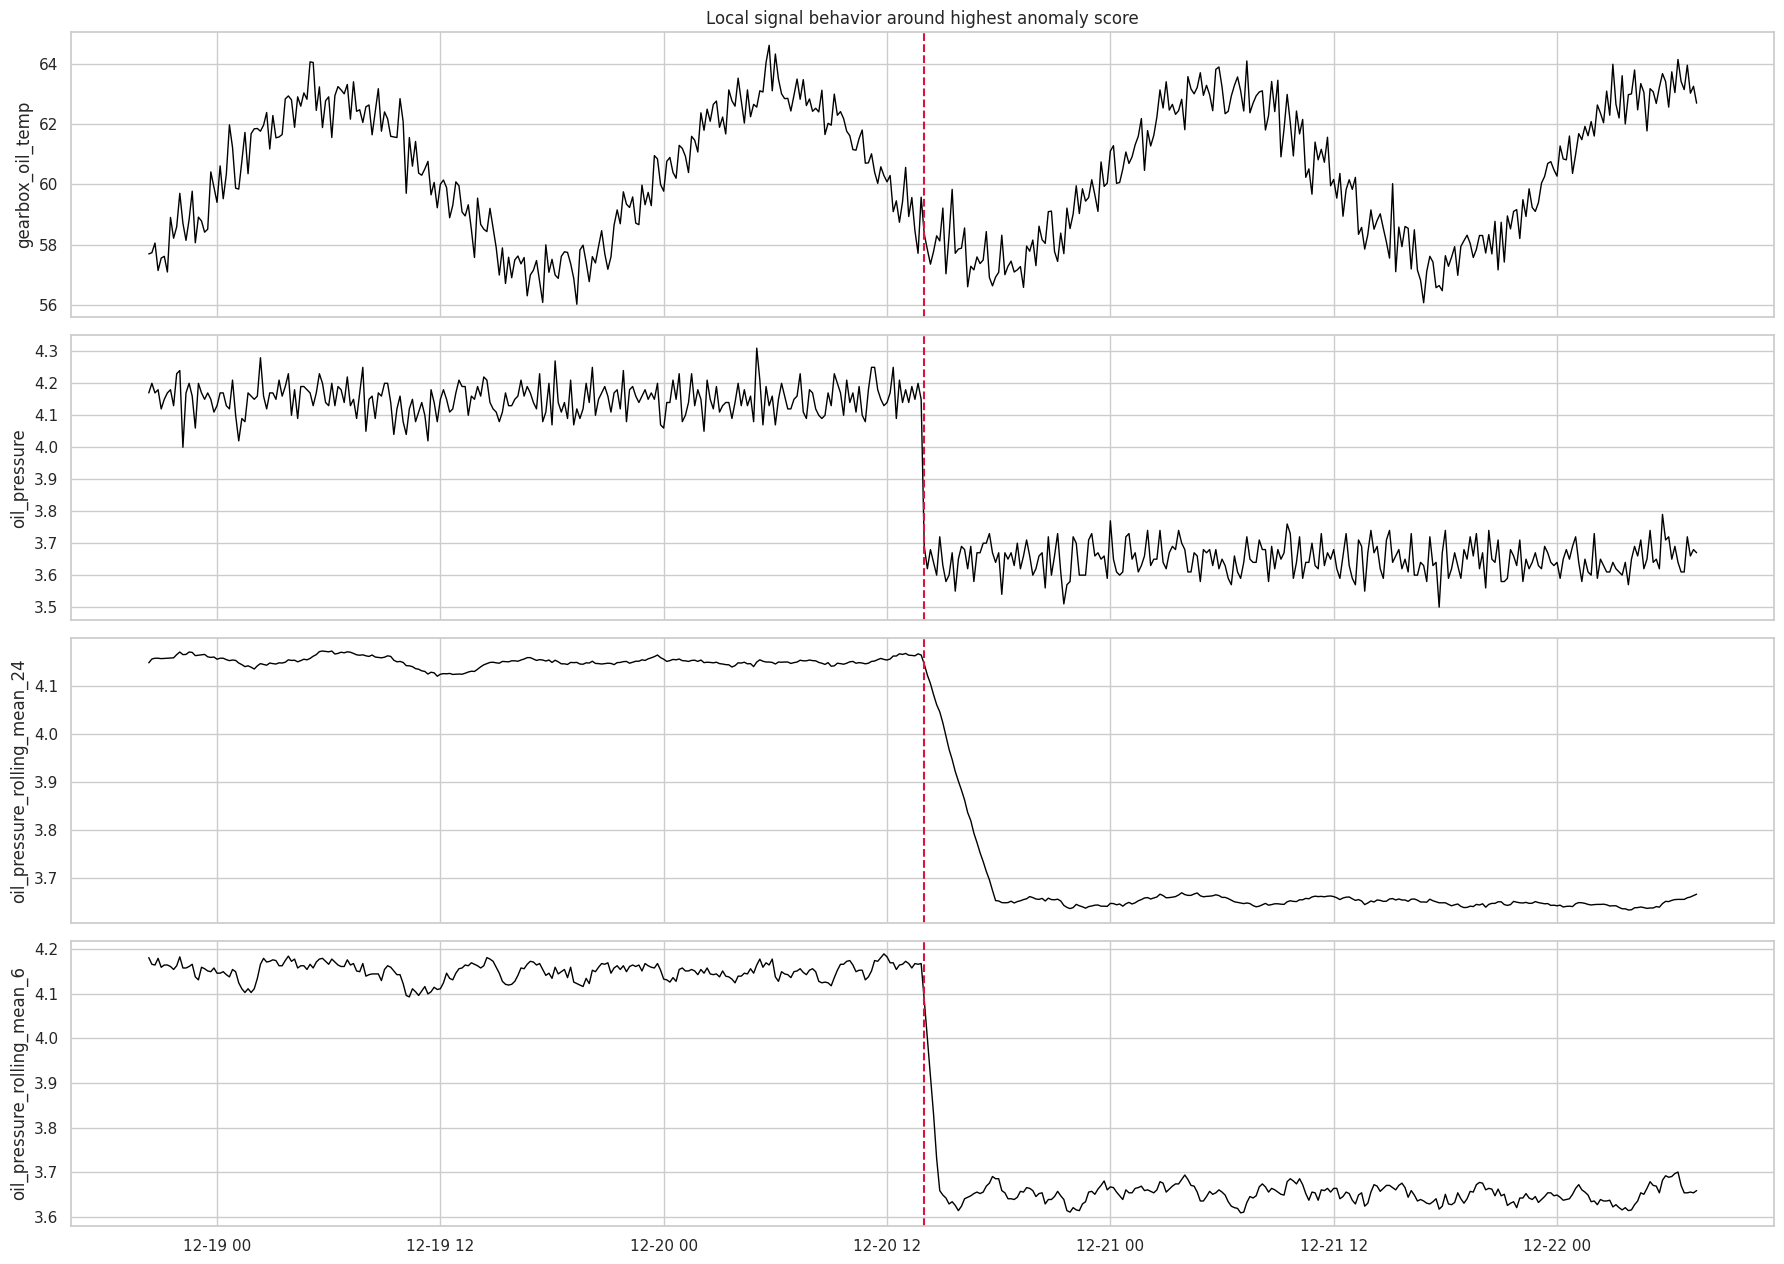

In [25]:
# Plot top features around the most anomalous test point.
if len(case_df) > 0:
    top_idx = case_df["anomaly_score"].idxmax()
    local_start = max(0, top_idx - 250)
    local_end = min(len(model_df), top_idx + 250)
    local_df = model_df.iloc[local_start:local_end].copy()

    if supervised_model is not None:
        plot_features = importance_df["feature"].head(4).tolist()
    else:
        plot_features = base_features[:4]

    fig, axes = plt.subplots(len(plot_features), 1, figsize=(18, 3.2 * len(plot_features)), sharex=True)
    if len(plot_features) == 1:
        axes = [axes]

    x_axis = local_df[datetime_col] if datetime_col else local_df.index
    for ax, feature in zip(axes, plot_features):
        ax.plot(x_axis, local_df[feature], color="black", linewidth=1)
        ax.set_ylabel(feature)
        ax.axvline(model_df.iloc[top_idx][datetime_col] if datetime_col else top_idx, color="crimson", linestyle="--")
    axes[0].set_title("Local signal behavior around highest anomaly score")
    plt.tight_layout()
    plt.show()

## 12. Save Artifacts

Save the trained models, feature list, and metadata for later use in an API or Streamlit dashboard.

In [26]:
artifact_dir = Path("../artifacts/wind_turbine_fault_detection")
artifact_dir.mkdir(parents=True, exist_ok=True)

metadata = {
    "dataset": "aiwithcagri/wind-turbine-gearbox-anomaly-detection-5year-scada",
    "data_file": data_file.name,
    "datetime_col": datetime_col,
    "target_col": target_col,
    "feature_count": len(engineered_features),
    "base_feature_count": len(base_features),
    "supervised_metrics": supervised_metrics,
}

joblib.dump(anomaly_model, artifact_dir / "isolation_forest_anomaly_model.pkl")
joblib.dump(engineered_features, artifact_dir / "feature_columns.pkl")

if supervised_model is not None:
    joblib.dump(supervised_model, artifact_dir / "random_forest_fault_classifier.pkl")

with (artifact_dir / "metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Artifacts saved to:", artifact_dir.resolve())

Artifacts saved to: /artifacts/wind_turbine_fault_detection


## 13. Next Steps

Recommended extensions:

1. Validate the exact meaning of the dataset target labels.
2. Add turbine/group-aware rolling features if a turbine identifier exists.
3. Compare Random Forest with gradient boosting models.
4. Tune decision thresholds for maintenance priorities, not only statistical accuracy.
5. Build an operational dashboard showing anomaly score, top drivers, and recent sensor behavior.

In [ ]:
feature_columns = [
    "gearbox_oil_temp",
    "gearbox_bearing_temp",
    "vibration_x",
    "vibration_y",
    "vibration_z",
    "oil_pressure",
    "particle_count"
]

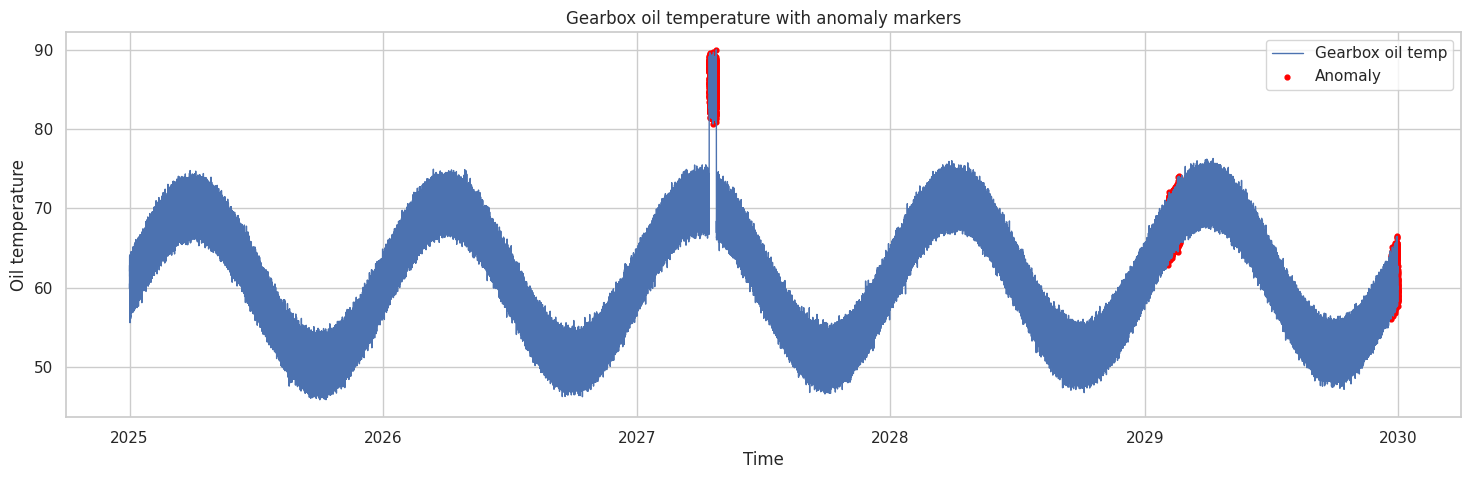

In [31]:
plt.figure(figsize=(18, 5))

plt.plot(
    df[datetime_col],
    df["gearbox_oil_temp"],
    linewidth=1,
    label="Gearbox oil temp"
)

plt.scatter(
    df.loc[df["is_fault"] == 1, datetime_col],
    df.loc[df["is_fault"] == 1, "gearbox_oil_temp"],
    color="red",
    s=12,
    label="Anomaly"
)

plt.title("Gearbox oil temperature with anomaly markers")
plt.xlabel("Time")
plt.ylabel("Oil temperature")
plt.legend()
plt.show()

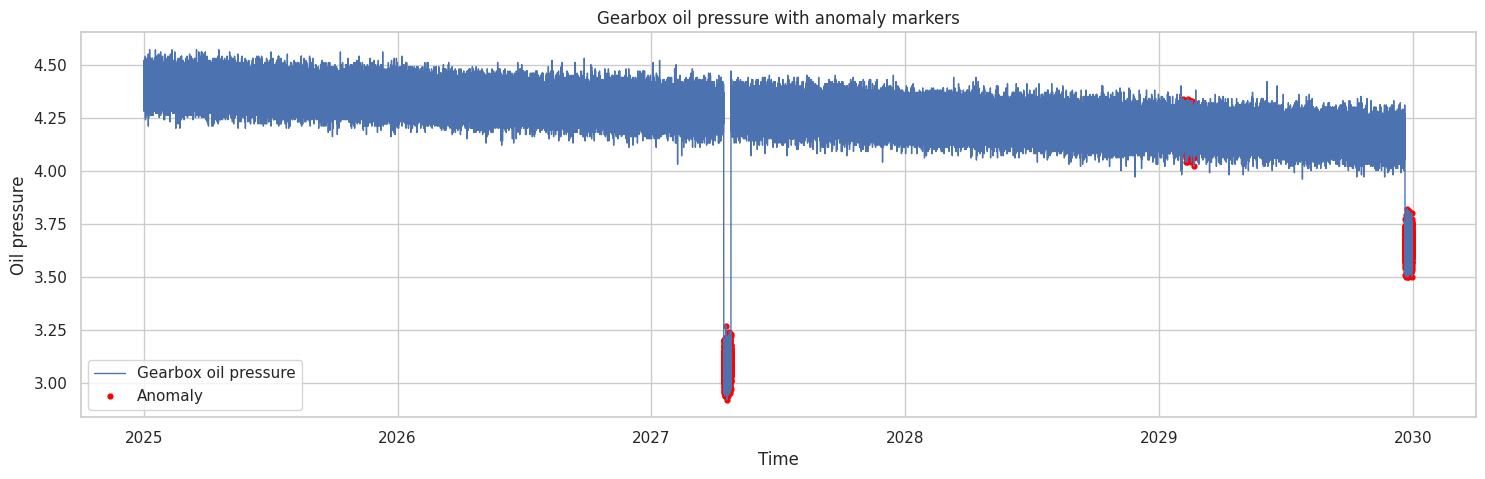

In [30]:
plt.figure(figsize=(18, 5))

plt.plot(
    df[datetime_col],
    df["oil_pressure"],
    linewidth=1,
    label="Gearbox oil pressure"
)

plt.scatter(
    df.loc[df["is_fault"] == 1, datetime_col],
    df.loc[df["is_fault"] == 1, "oil_pressure"],
    color="red",
    s=12,
    label="Anomaly"
)

plt.title("Gearbox oil pressure with anomaly markers")
plt.xlabel("Time")
plt.ylabel("Oil pressure")
plt.legend()
plt.show()

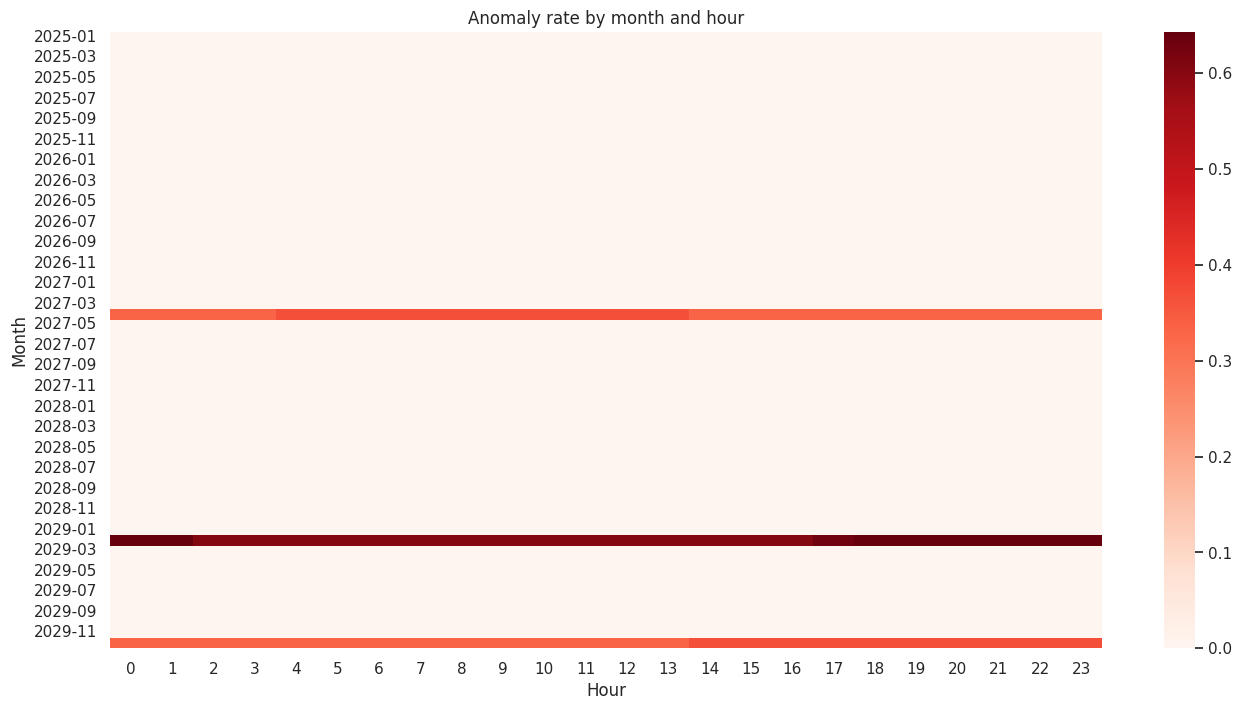

In [32]:
tmp = df.copy()
tmp["month"] = tmp[datetime_col].dt.to_period("M").astype(str)
tmp["hour"] = tmp[datetime_col].dt.hour

heatmap_data = (
    tmp.groupby(["month", "hour"])["is_fault"]
    .mean()
    .reset_index()
    .pivot(index="month", columns="hour", values="is_fault")
)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap="Reds")
plt.title("Anomaly rate by month and hour")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.show()

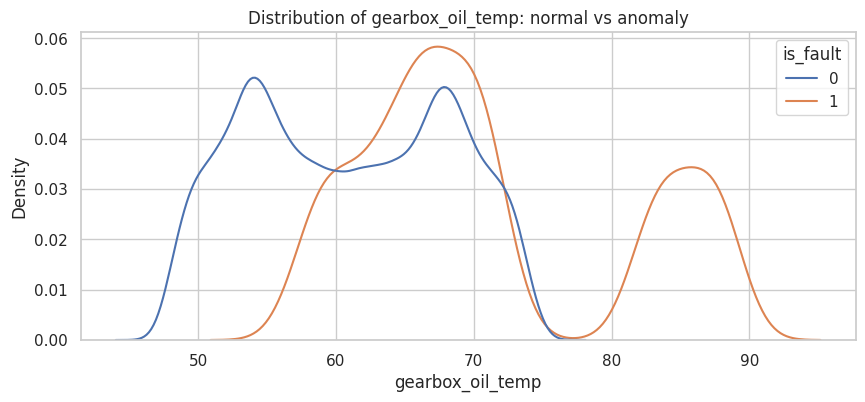

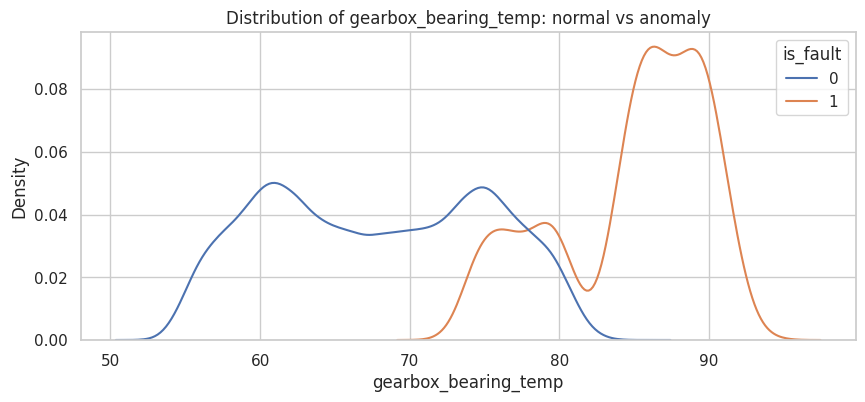

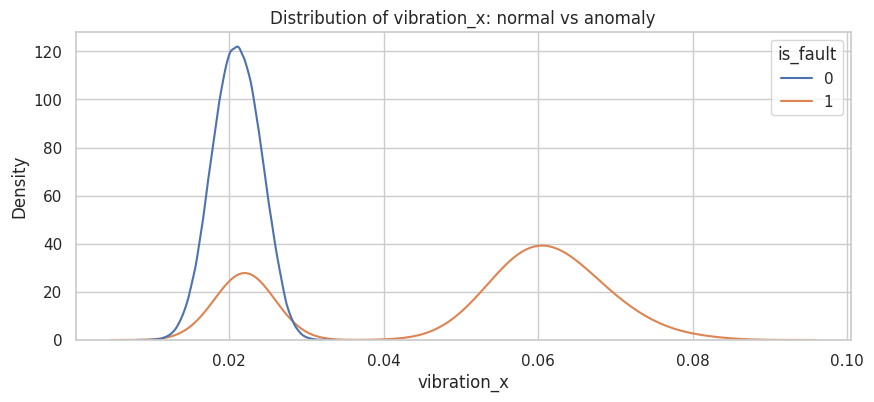

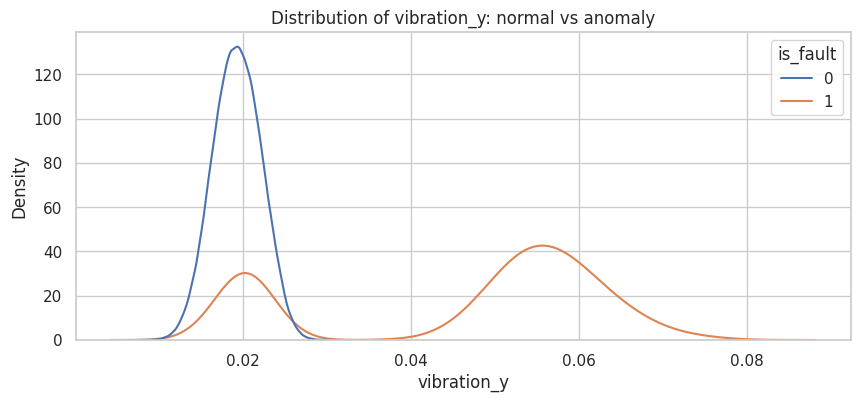

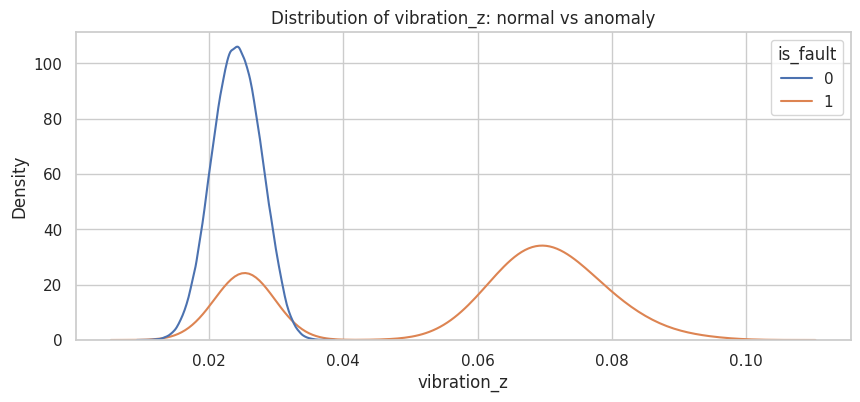

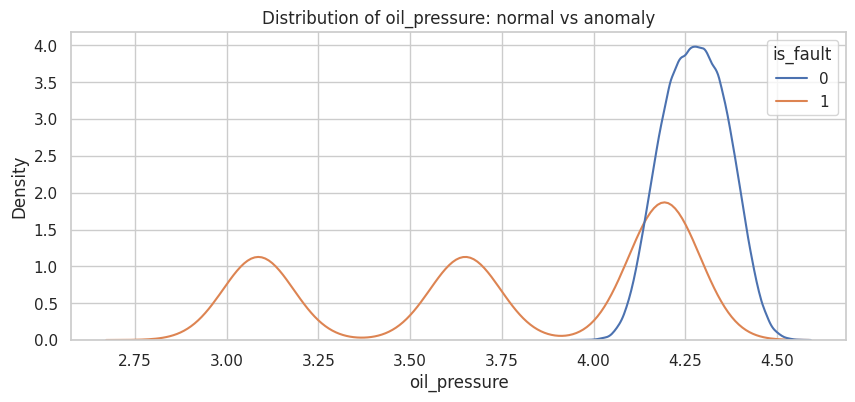

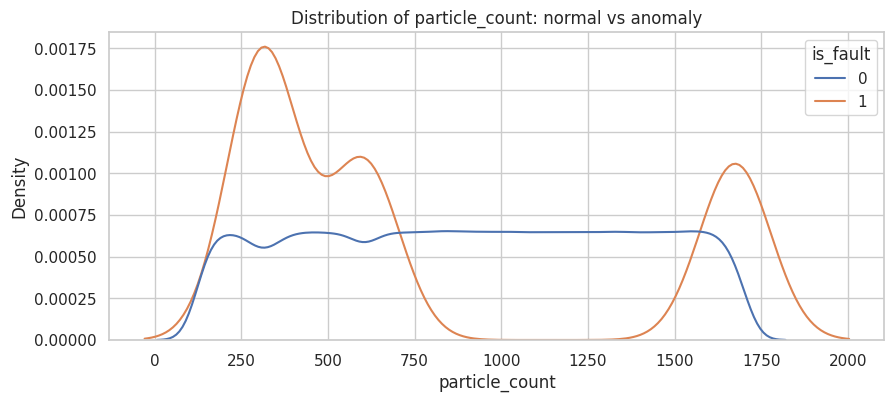

In [33]:
signals = [
    "gearbox_oil_temp",
    "gearbox_bearing_temp",
    "vibration_x",
    "vibration_y",
    "vibration_z",
    "oil_pressure",
    "particle_count"
]

for col in signals:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df, x=col, hue="is_fault", common_norm=False)
    plt.title(f"Distribution of {col}: normal vs anomaly")
    plt.show()